In [1]:
import time
import neost
from neost.eos import polytropes
from neost.Prior import Prior
from neost.Star import Star
from neost.Likelihood import Likelihood
from scipy.stats import multivariate_normal
from neost import PosteriorAnalysis
import numpy as np
import matplotlib.pyplot as plt
import timeit
import neost.global_imports as global_imports
from matplotlib.patches import Ellipse

start = time.time()
c = global_imports._c
G = global_imports._G
Msun = global_imports._M_s
pi = global_imports._pi
rho_ns = global_imports._rhons

In [2]:
print(np.log10(4*rho_ns))

15.030185068848917


In [3]:
EOS = polytropes.PolytropicEoS(crust='ceft-Hebeler', rho_t= 1.1*rho_ns,adm_type = 'None')

#Can produce interesting MR relations
EOS.update({'gamma1':3.8, 'gamma2':3.8, 'gamma3':2.2, 'rho_t1':1.8, 'rho_t2':2.7, 'ceft': 2.6}, max_edsc=True)

In [4]:
central_densities = np.logspace(14.6, np.log10(EOS.max_edsc),100)
MR2 = np.zeros((len(central_densities), 2))
for i, eps in enumerate(central_densities):
    star = Star(eps)
    star.solve_structure(EOS.energydensities, EOS.pressures)
    MR2[i] = star.Mrot, star.Req


end = time.time()

print(MR2[:,0])
print("Execution time of the MR is: " + str(end-start)) 

[0.49809863 0.51946956 0.54200371 0.56480069 0.58876587 0.6137714
 0.63882568 0.66505535 0.69248789 0.71999973 0.74869825 0.77863861
 0.80857749 0.83969303 0.87117106 0.90421716 0.93638615 0.97101346
 1.00548232 1.03949007 1.07455748 1.11065561 1.14779714 1.18436626
 1.22186517 1.25888592 1.29778747 1.33582937 1.37460553 1.41238515
 1.45078956 1.48976901 1.52864983 1.56762672 1.6056999  1.64387447
 1.68232708 1.71929534 1.75641043 1.79364063 1.83095731 1.86660458
 1.9022403  1.93778456 1.97077115 1.99054076 2.00977518 2.02847322
 2.0461567  2.06321707 2.07975327 2.09569643 2.11108433 2.12597916
 2.14046158 2.1546345  2.16832472 2.18153342 2.19388116 2.20578721
 2.21725696 2.22823755 2.23877388 2.24890235 2.25859648 2.26785124
 2.27672092 2.28520822 2.29346752 2.30133936 2.3088876  2.31592002
 2.32252194 2.32879454 2.33473214 2.34030951 2.34557737 2.35053416
 2.35524546 2.3596876  2.3638431  2.3676761  2.37113056 2.37433827
 2.37727444 2.37992949 2.38234915 2.38451054 2.38644055 2.38815

In [5]:
EOS = polytropes.PolytropicEoS(crust='ceft-Hebeler', rho_t= 1.1*rho_ns,adm_type = 'Dark Energy')

#Can produce interesting MR relations
EOS.update({'gamma1':3.8, 'gamma2':3.8, 'gamma3':2.2, 'rho_t1':1.8, 'rho_t2':2.7, 'A_param': 0.3, 'alpha': 0.8, 'rho_plus': 2., 'ceft': 2.6}, max_edsc_de=True)

##EOS.update({'gamma1':3.8, 'gamma2':3.8, 'gamma3':2.2, 'rho_t1':1.8, 'rho_t2':2.7

#EOS.update({'gamma1':3.3, 'gamma2':4., 'gamma3':2.6, 'rho_t1':1.8, 'rho_t2':2.7
#EOS.update({'gamma1':2.3, 'gamma2':4., 'gamma3':2.6, 'rho_t1':1.8, 'rho_t2':4,


central_densities = np.linspace(EOS.rho_plus/rho_ns+0.1, EOS.max_edsc_de, 100)*rho_ns
MR = np.zeros((len(central_densities), 3))


for i, eps in enumerate(central_densities):
    star = Star(eps,0.0,EOS.rho_plus, EOS.alpha, False, True)
    star.solve_structure(EOS.energydensities, EOS.pressures, EOS.energydensities_de, EOS.pressures_de)
    MR[i] = star.Mrot, star.Req, star.Mdm


end = time.time()

print(np.log10(4.*rho_ns))
print(MR[:,0][-1],MR[:,1][-1]) 

/home/nr1118/anaconda3/envs/neost/lib/python3.12/site-packages/neost/tovsolvers/TOVde_python.py:192: RuntimeWarning: invalid value encountered in log10
  indx = np.isnan(np.log10(eos_presde))
/home/nr1118/anaconda3/envs/neost/lib/python3.12/site-packages/neost/tovsolvers/TOVde_python.py:192: RuntimeWarning: invalid value encountered in log10
  indx = np.isnan(np.log10(eos_presde))


15.030185068848917
2.1282570237640357 11.917601294963477


In [6]:
EOS = polytropes.PolytropicEoS(crust='ceft-Hebeler', rho_t= 1.1*rho_ns,adm_type = 'Dark Energy')

#Can produce interesting MR relations
EOS.update({'gamma1':3.8, 'gamma2':3.8, 'gamma3':2.2, 'rho_t1':1.8, 'rho_t2':2.7, 'A_param': 0.3, 'alpha': 0.2, 'rho_plus': 2., 'ceft': 2.6}, max_edsc_de=True)

##EOS.update({'gamma1':3.8, 'gamma2':3.8, 'gamma3':2.2, 'rho_t1':1.8, 'rho_t2':2.7

#EOS.update({'gamma1':3.3, 'gamma2':4., 'gamma3':2.6, 'rho_t1':1.8, 'rho_t2':2.7
#EOS.update({'gamma1':2.3, 'gamma2':4., 'gamma3':2.6, 'rho_t1':1.8, 'rho_t2':4,


central_densities = np.linspace(EOS.rho_plus/rho_ns+0.1, EOS.max_edsc_de, 100)*rho_ns
MR1 = np.zeros((len(central_densities), 3))


for i, eps in enumerate(central_densities):
    star = Star(eps,0.0,EOS.rho_plus, EOS.alpha, False, True)
    star.solve_structure(EOS.energydensities, EOS.pressures, EOS.energydensities_de, EOS.pressures_de)
    MR1[i] = star.Mrot, star.Req, star.Mdm


end = time.time()

print(np.log10(4.0*rho_ns))
print(MR1[:,0][-1],MR1[:,1][-1])

print(abs(MR1[:,1]-MR[:,1])/MR[:,1]*100)

15.030185068848917
2.036504022112035 10.986523453831555
[26.84622424 27.97500228 25.95986906 23.84776271 21.88296415 20.22126975
 18.7886259  17.62447757 16.59761787 15.74617405 15.0061804  14.35405306
 13.80134165 13.31290633 12.86777554 12.48099079 12.14858745 11.82875951
 11.54187288 11.31619533 11.07097212 10.88011115 10.68329008 10.49839873
 10.36397114 10.20783259 10.06157316  9.91844075  9.80045065  9.69408705
  9.61139783  9.51275677  9.44122864  9.36494034  9.28233825  9.20809196
  9.14179011  9.07642266  9.0176616   8.96696965  8.90668119  8.85281808
  8.80521518  8.76604072  8.71839349  8.67359667  8.63273971  8.59166441
  8.54430475  8.53789105  8.50895079  8.47866502  8.42771229  8.40876534
  8.38456915  8.3614187   8.33371668  8.3113018   8.28069329  8.26173507
  8.22162631  8.21538497  8.19874684  8.18613668  8.16631145  8.14587218
  8.12397257  8.11265597  8.0994668   8.08390247  8.06744192  8.05816597
  8.03581612  8.02824067  8.02182827  8.00969758  7.9973897   7.9860

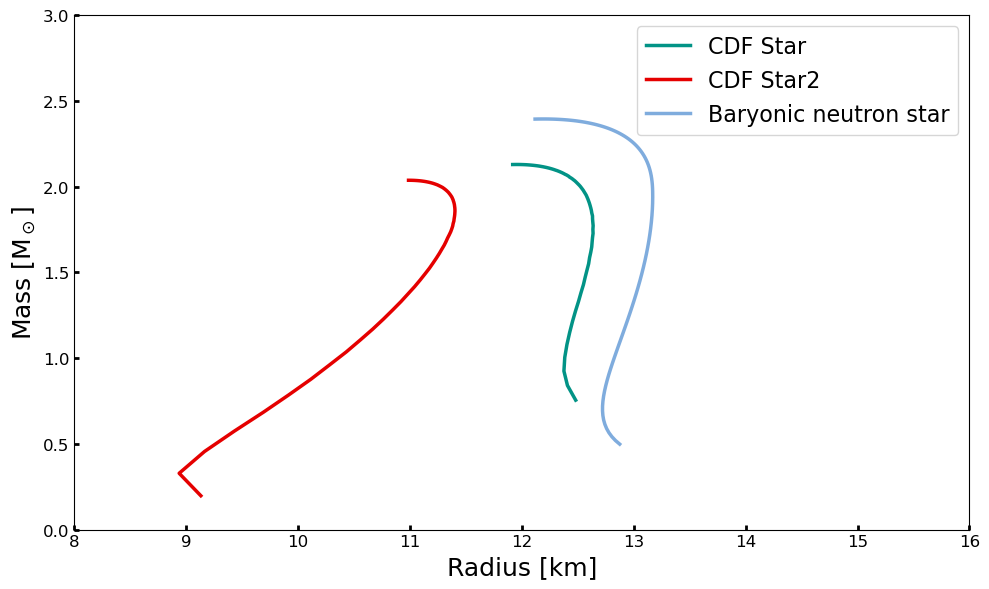

In [7]:
fig, ax = plt.subplots(1,1, figsize=(10, 6))
ax.plot(MR[:,1], MR[:,0],label='CDF Star', lw=2.5,color = 'xkcd:teal')
ax.plot(MR1[:,1], MR1[:,0],label='CDF Star2', lw=2.5,color = 'xkcd:red')
lns2 = ax.plot(MR2[:,1], MR2[:,0], label='Baryonic neutron star', lw=2.5,alpha = 0.5,color = '#005ABD')
ax.set_ylim(0.,3.)
ax.set_xlim(8,16)


ax.set_xlabel(r'Radius [km]', fontsize=18)
ax.set_ylabel(r'Mass [M$_\odot$]', fontsize=18)
ax.tick_params(width=2, labelsize=12, direction='in')
#lns = lns1+lns2
#labs = [l.get_label() for l in lns]
ax.legend(loc='best', fontsize=16)
#ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,fontsize=22)

#for axis in ['top', 'bottom', 'left', 'right']:
    #ax.spines[axis].set_linewidth(1.5)
plt.tight_layout()
plt.show()

#print('ADM energy density in units of g/cm^3')
k=0
for i, eps in enumerate(central_densities):
    
    if np.log10(EOS.rho_plus) < np.log10(eps):
        star = Star(eps,0.0,EOS.rho_plus, EOS.alpha, False, True)
        star.solve_structure(EOS.energydensities, EOS.pressures, EOS.energydensities_de, EOS.pressures_de)
        Mrot = star.Mrot
        Req = star.Req
        Mde = star.Mdm
        

    else:
        star = Star(eps)
        star.solve_structure(EOS.energydensities, EOS.pressures)
        Mrot = star.Mrot
        Req = star.Req
        Mde = star.Mdm
        k = k+1
        

    MR[i] = Mrot, Req, Mde


end = time.time()

print("Execution time of the MR is: " + str(end-start)) 


#print(MR[:,1])
#print(MR[:,0])

fig, ax = plt.subplots(1,1, figsize=(10, 6))
ax.plot(MR[:,1][0:k], MR[:,0][0:k],label='Baryonic branch', lw=2.5,color = 'xkcd:tomato')
ax.plot(MR[:,1][k+1:], MR[:,0][k+1:],label='Dark energy core branch', lw=2.5,color = '#00B1B7')
#lns2 = ax.plot(EOS.massradius[:,1], EOS.massradius[:,0], label='Baryonic neutron star', lw=2.5,alpha = 0.5,color = '#005ABD')
ax.set_ylim(0.,2.75)
ax.set_xlim(8,16)


ax.set_xlabel(r'Radius [km]', fontsize=18)
ax.set_ylabel(r'Mass [M$_\odot$]', fontsize=18)
ax.tick_params(width=2, labelsize=12, direction='in')
#lns = lns1+lns2
#labs = [l.get_label() for l in lns]
ax.legend(loc='best', fontsize=16)
#ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,fontsize=22)

#for axis in ['top', 'bottom', 'left', 'right']:
    #ax.spines[axis].set_linewidth(1.5)
plt.tight_layout()
plt.show()
fig.savefig('MR_interesting.pdf')

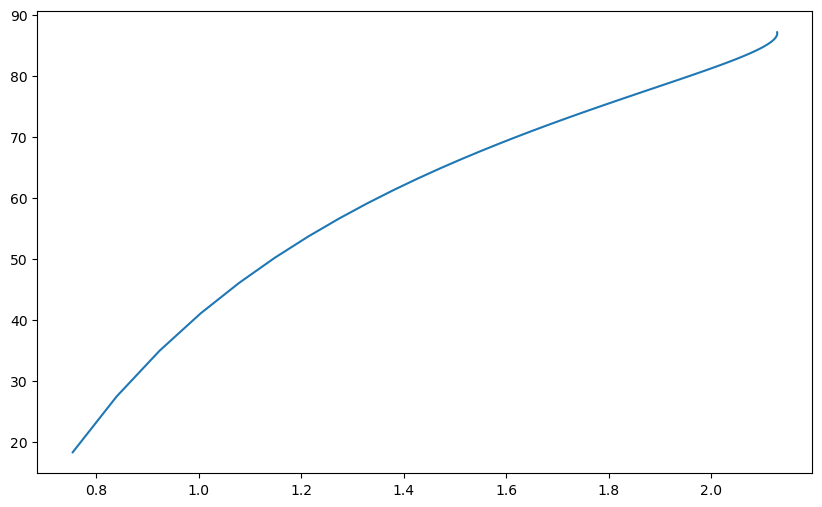

In [8]:
F_DE = MR[:,2]/MR[:,0]*100
fig, ax = plt.subplots(1,1, figsize=(10, 6))
ax.plot(MR[:,0], F_DE)